## 1. IMPORT LIBRARIES

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

## 2. LOAD DATASET

In [9]:
data = pd.read_csv("cleaned_titanic_dataset.csv")

print("Dataset loaded successfully!")
print("Dataset Shape:", data.shape)

print("\nFirst 5 Rows:")
print(data.head())

Dataset loaded successfully!
Dataset Shape: (418, 12)

First 5 Rows:
   PassengerId  Survived  Pclass  \
0          892         0       3   
1          893         1       3   
2          894         0       2   
3          895         0       3   
4          896         1       3   

                                           Name     Sex   Age  SibSp  Parch  \
0                              Kelly, Mr. James    male  34.5      0      0   
1              Wilkes, Mrs. James (Ellen Needs)  female  47.0      1      0   
2                     Myles, Mr. Thomas Francis    male  62.0      0      0   
3                              Wirz, Mr. Albert    male  27.0      0      0   
4  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female  22.0      1      1   

    Ticket     Fare Cabin Embarked  
0   330911   7.8292   NaN        Q  
1   363272   7.0000   NaN        S  
2   240276   9.6875   NaN        Q  
3   315154   8.6625   NaN        S  
4  3101298  12.2875   NaN        S  


## 3. BASIC DATASET INFORMATION

In [10]:
print("\n" + "="*60)
print("DATASET INFORMATION")
print("="*60)

print("\nColumn Names:")
print(data.columns.tolist())

print("\nDataset Information:")
data.info()

print("\nStatistical Summary:")
print(data.describe())


DATASET INFORMATION

Column Names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          418 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         418 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB

Statistical Summary:
       PassengerId    Survived      Pclass     

## 4. CHECK MISSING VALUES

In [11]:
print("\n" + "="*60)
print("MISSING VALUES")
print("="*60)

print(data.isnull().sum())


MISSING VALUES
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          327
Embarked         0
dtype: int64


## 5. CHECK DUPLICATES

In [12]:
print("\n" + "="*60)
print("DUPLICATE CHECK")
print("="*60)

print("Duplicate Rows:", data.duplicated().sum())


DUPLICATE CHECK
Duplicate Rows: 0


## 6. TARGET DISTRIBUTION

In [13]:
print("\n" + "="*60)
print("TARGET DISTRIBUTION")
print("="*60)

print(data["Survived"].value_counts())

print("\nTarget Percentage:")
print(data["Survived"].value_counts(normalize=True) * 100)


TARGET DISTRIBUTION
Survived
0    266
1    152
Name: count, dtype: int64

Target Percentage:
Survived
0    63.636364
1    36.363636
Name: proportion, dtype: float64


## 7. SELECT FEATURES AND TARGET

In [14]:
features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

X = data[features]
y = data["Survived"]

print("\nSelected Features:")
print(X.columns.tolist())

print("\nTarget Variable:")
print("Survived")


Selected Features:
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

Target Variable:
Survived


## 8. OUTLIER DETECTION

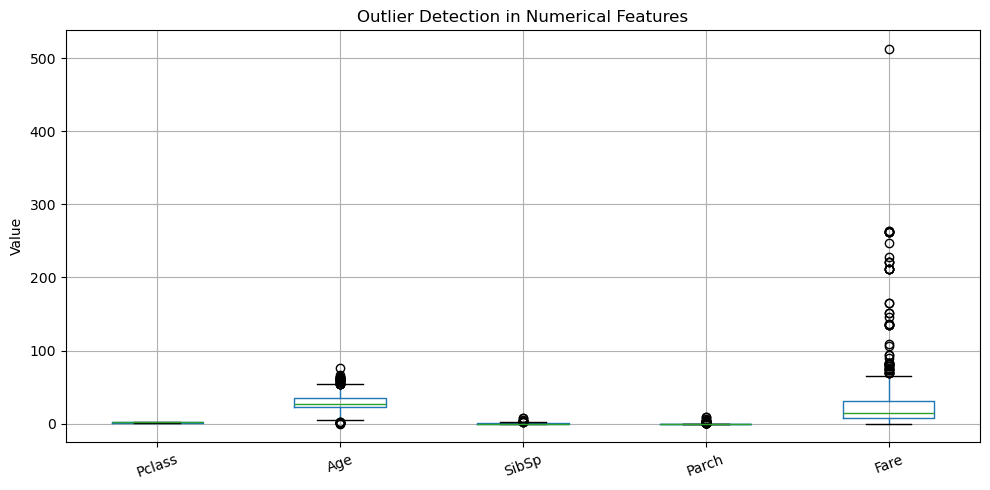

In [15]:
numeric_features = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

plt.figure(figsize=(10, 5))

data[numeric_features].boxplot()

plt.title("Outlier Detection in Numerical Features")
plt.ylabel("Value")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 9. TRAIN TEST SPLIT

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n" + "="*60)
print("TRAIN TEST SPLIT")
print("="*60)

print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)


TRAIN TEST SPLIT
Training Data: (334, 7)
Testing Data : (84, 7)


## 10. DEFINE NUMERICAL AND CATEGORICAL FEATURES

In [17]:
numeric_features = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

categorical_features = [
    "Sex",
    "Embarked"
]

## 11. NUMERICAL PREPROCESSING

In [18]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

## 12. CATEGORICAL PREPROCESSING

In [19]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        drop="first",
        handle_unknown="ignore"
    ))
])

## 13. COMBINE PREPROCESSING

In [20]:
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

## 14. BASELINE LOGISTIC REGRESSION MODEL

In [21]:
baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

## 15. TRAIN BASELINE MODEL

In [22]:
baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)

## 16. BASELINE MODEL EVALUATION

In [23]:
baseline_accuracy = accuracy_score(
    y_test,
    baseline_pred
)

baseline_precision = precision_score(
    y_test,
    baseline_pred
)

baseline_recall = recall_score(
    y_test,
    baseline_pred
)

baseline_f1 = f1_score(
    y_test,
    baseline_pred
)

print("\n" + "="*60)
print("BASELINE MODEL RESULTS")
print("="*60)

print("Accuracy :", round(baseline_accuracy, 4))
print("Precision:", round(baseline_precision, 4))
print("Recall   :", round(baseline_recall, 4))
print("F1 Score :", round(baseline_f1, 4))


BASELINE MODEL RESULTS
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


## 17. BASELINE CLASSIFICATION REPORT

In [24]:
print("\nBaseline Classification Report:")
print(
    classification_report(
        y_test,
        baseline_pred
    )
)


Baseline Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       1.00      1.00      1.00        31

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



## 18. BASELINE CONFUSION MATRIX

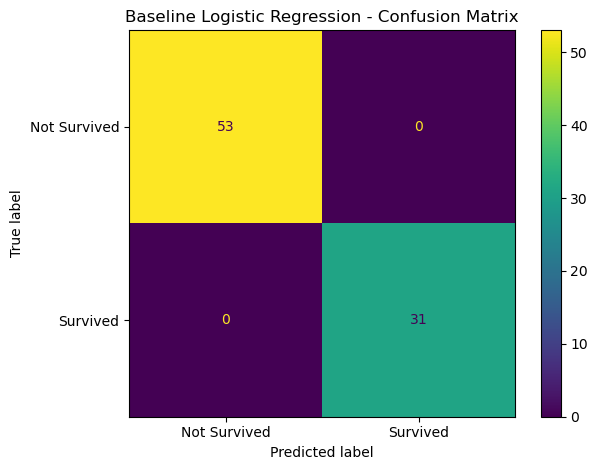

In [25]:
baseline_cm = confusion_matrix(
    y_test,
    baseline_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=baseline_cm,
    display_labels=["Not Survived", "Survived"]
)

disp.plot()

plt.title("Baseline Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

## 19. FIVE-FOLD CROSS VALIDATION

In [26]:
cv_scores = cross_val_score(
    baseline_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("\n" + "="*60)
print("5-FOLD CROSS VALIDATION")
print("="*60)

print("Fold 1:", round(cv_scores[0], 4))
print("Fold 2:", round(cv_scores[1], 4))
print("Fold 3:", round(cv_scores[2], 4))
print("Fold 4:", round(cv_scores[3], 4))
print("Fold 5:", round(cv_scores[4], 4))

print("\nMean CV Accuracy:",
      round(cv_scores.mean(), 4))

print("CV Standard Deviation:",
      round(cv_scores.std(), 4))


5-FOLD CROSS VALIDATION
Fold 1: 1.0
Fold 2: 1.0
Fold 3: 1.0
Fold 4: 1.0
Fold 5: 1.0

Mean CV Accuracy: 1.0
CV Standard Deviation: 0.0


## 20. CREATE MODEL PIPELINE FOR GRIDSEARCH

In [27]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

## 21. DEFINE HYPERPARAMETER GRID

In [28]:
param_grid = {
    "classifier__C": [
        0.01,
        0.1,
        1,
        10,
        100
    ]
}

## 22. GRIDSEARCHCV

In [29]:
grid_search = GridSearchCV(
    estimator=model_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(
    X_train,
    y_train
)

,estimator,Pipeline(step..._iter=1000))])
,param_grid,"{'classifier__C': [0.01, 0.1, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('numeric', ...), ('categorical', ...)]"


## 23. BEST PARAMETERS

In [30]:
print("\n" + "="*60)
print("GRIDSEARCH RESULTS")
print("="*60)

print("Best Parameters:")
print(grid_search.best_params_)

print(
    "\nBest Cross Validation Accuracy:",
    round(grid_search.best_score_, 4)
)


GRIDSEARCH RESULTS
Best Parameters:
{'classifier__C': 1}

Best Cross Validation Accuracy: 1.0


## 24. SHOW ALL GRIDSEARCH RESULTS

In [31]:
grid_results = pd.DataFrame(
    grid_search.cv_results_
)

grid_results = grid_results[
    [
        "param_classifier__C",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values(
    "rank_test_score"
)

print("\nAll Hyperparameter Results:")
print(grid_results.to_string(index=False))


All Hyperparameter Results:
 param_classifier__C  mean_test_score  std_test_score  rank_test_score
                1.00         1.000000         0.00000                1
               10.00         1.000000         0.00000                1
              100.00         1.000000         0.00000                1
                0.10         0.997015         0.00597                4
                0.01         0.703618         0.01401                5


## 25. GET BEST MODEL

In [32]:
tuned_model = grid_search.best_estimator_

## 26. MAKE PREDICTIONS USING TUNED MODEL

In [33]:
tuned_pred = tuned_model.predict(X_test)

## 27. TUNED MODEL EVALUATION

In [34]:
tuned_accuracy = accuracy_score(
    y_test,
    tuned_pred
)

tuned_precision = precision_score(
    y_test,
    tuned_pred
)

tuned_recall = recall_score(
    y_test,
    tuned_pred
)

tuned_f1 = f1_score(
    y_test,
    tuned_pred
)

print("\n" + "="*60)
print("TUNED MODEL RESULTS")
print("="*60)

print("Accuracy :", round(tuned_accuracy, 4))
print("Precision:", round(tuned_precision, 4))
print("Recall   :", round(tuned_recall, 4))
print("F1 Score :", round(tuned_f1, 4))


TUNED MODEL RESULTS
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


## 28. TUNED CLASSIFICATION REPORT

In [35]:
print("\nTuned Classification Report:")

print(
    classification_report(
        y_test,
        tuned_pred
    )
)


Tuned Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       1.00      1.00      1.00        31

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



## 29. TUNED CONFUSION MATRIX

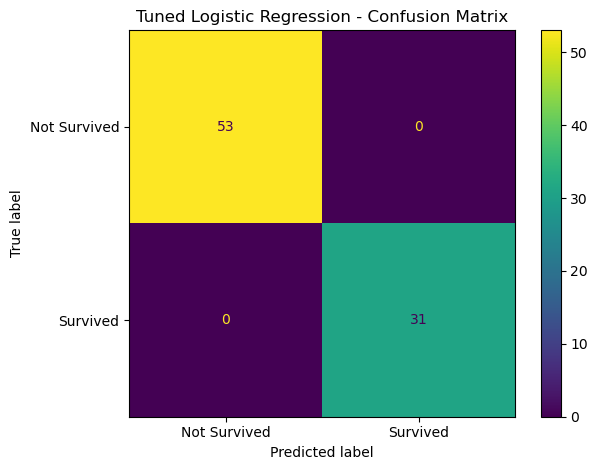

In [36]:
tuned_cm = confusion_matrix(
    y_test,
    tuned_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=tuned_cm,
    display_labels=["Not Survived", "Survived"]
)

disp.plot()

plt.title("Tuned Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

## 30. BASELINE VS TUNED COMPARISON

In [37]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Baseline Model": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1
    ],

    "Tuned Model": [
        tuned_accuracy,
        tuned_precision,
        tuned_recall,
        tuned_f1
    ]
})

print("\n" + "="*60)
print("BASELINE VS TUNED MODEL")
print("="*60)

print(
    comparison.to_string(index=False)
)


BASELINE VS TUNED MODEL
   Metric  Baseline Model  Tuned Model
 Accuracy             1.0          1.0
Precision             1.0          1.0
   Recall             1.0          1.0
 F1 Score             1.0          1.0


## 31. CALCULATE IMPROVEMENT

In [38]:
accuracy_change = tuned_accuracy - baseline_accuracy
precision_change = tuned_precision - baseline_precision
recall_change = tuned_recall - baseline_recall
f1_change = tuned_f1 - baseline_f1

print("\n" + "="*60)
print("CHANGE AFTER TUNING")
print("="*60)

print(
    "Accuracy Change :",
    round(accuracy_change, 4)
)

print(
    "Precision Change:",
    round(precision_change, 4)
)

print(
    "Recall Change   :",
    round(recall_change, 4)
)

print(
    "F1 Score Change :",
    round(f1_change, 4)
)


CHANGE AFTER TUNING
Accuracy Change : 0.0
Precision Change: 0.0
Recall Change   : 0.0
F1 Score Change : 0.0


## 32. FINAL SUMMARY

In [39]:
print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)

print("Dataset Shape:", data.shape)

print(
    "Baseline Accuracy:",
    round(baseline_accuracy, 4)
)

print(
    "Mean 5-Fold CV Accuracy:",
    round(cv_scores.mean(), 4)
)

print(
    "Best CV Accuracy:",
    round(grid_search.best_score_, 4)
)

print(
    "Tuned Test Accuracy:",
    round(tuned_accuracy, 4)
)

print(
    "Best Parameters:",
    grid_search.best_params_
)

print("\nWeek 8 analysis completed successfully!")


FINAL SUMMARY
Dataset Shape: (418, 12)
Baseline Accuracy: 1.0
Mean 5-Fold CV Accuracy: 1.0
Best CV Accuracy: 1.0
Tuned Test Accuracy: 1.0
Best Parameters: {'classifier__C': 1}

Week 8 analysis completed successfully!
